<a href="https://colab.research.google.com/github/surbhisngh6-byte/Python_Car_Project/blob/main/Copy_of_Surbhi_Singh_CPDA_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Used Car Price Analysis using Python & Pandas**

**Prepared By:** Surbhi Singh, **Date:** 31-05-2026

**Objective** - The objective of this analysis is to perform data cleaning, exploratory data analysis (EDA), and business insights generation using the car_prices dataset. The analysis focuses on understanding vehicle pricing trends, identifying data quality issues, and deriving actionable insights from the used car market.

# 1. Data Ingestion & Quality Profiling

In [92]:
import pandas as pd

In [93]:
import os
os.listdir()

['.config', 'sample_data']

In [94]:
df=pd.read_csv("/car_prices.csv")

## 1.1 Load and Inspect the Dataset

In [95]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


**Observation** - The dataset contains used car listings with attributes such as make, model, year, transmission, condition, odometer reading, state, and selling price. Understanding the structure helps identify data quality issues and select appropriate analysis techniques.

## 1.2 Understanding the Data Structure

In [96]:
df.shape

(558837, 16)

In [97]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


**Observation** - The dataset contains 558,837 records and 16 columns. The data includes vehicle specifications, condition metrics, location information, and pricing details suitable for exploratory data analysis. The dataset contains used car listings with attributes such as make, model, year, transmission, condition, odometer reading, state and selling price. Understanding the structure helps identify data quality issues and select appropriate analysis techniques.

## 1.3 Missing Value & Duplicate Analysis

In [99]:
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


**Observation:** Missing values are present in multiple categorical columns, with the transmission column having the highest number of missing records. Data cleaning is required to ensure accurate analysis and prevent biased results.

In [100]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
transmission,11.694287
body,2.361154
condition,2.115107
trim,1.905922
model,1.860829
make,1.843292
color,0.134028
interior,0.134028
odometer,0.016821
mmr,0.006800


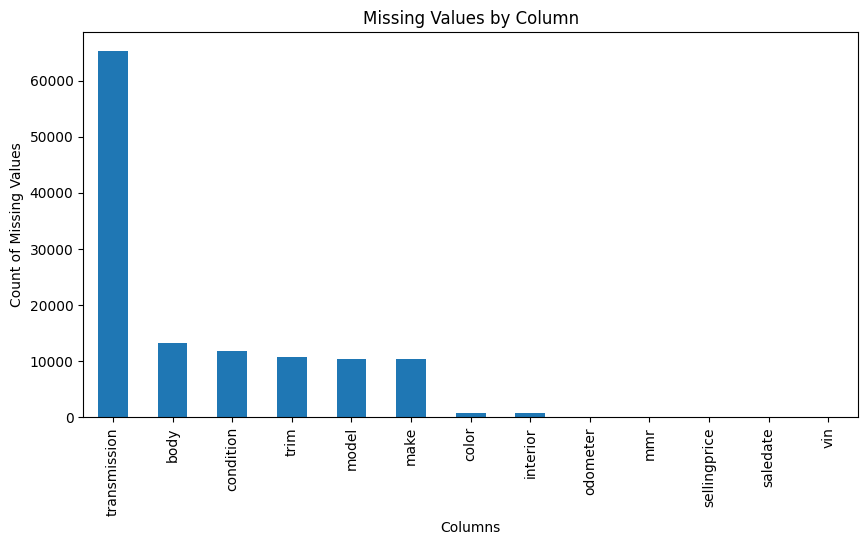

In [101]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.show()

**Insight:** The transmission column contains significantly more missing values than other fields. However, the percentage of missing values is still relatively small compared to the total dataset size, making imputation a suitable data-cleaning approach.

In [102]:
categorical_cols = [
    'make',
    'model',
    'trim',
    'body',
    'transmission',
    'color',
    'interior'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [103]:
df['condition'] = df['condition'].fillna(df['condition'].median())
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['sellingprice'] = df['sellingprice'].fillna(df['sellingprice'].median())

In [104]:
df.isnull().sum()

,0
year,0
make,0
model,0
trim,0
body,0
transmission,0
vin,4
state,0
condition,0
odometer,0


In [105]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


**Observation:**
No duplicate records were found in the dataset. This indicates that each record represents a unique vehicle listing and no duplicate removal was required.

# 2. DataFrame Queries

**Section Overview:**This section answers business-focused questions using filtering, grouping, aggregation, and feature engineering techniques in Pandas. The objective is to uncover pricing trends, vehicle characteristics, and market insights from the used car dataset.

## 2.1 Average, Minimum and Maximum Selling Price

In [106]:
print("Average Selling Price:", df['sellingprice'].mean())
print("Minimum Selling Price:", df['sellingprice'].min())
print("Maximum Selling Price:", df['sellingprice'].max())

Average Selling Price: 13611.326356343621
Minimum Selling Price: 1.0
Maximum Selling Price: 230000.0


**Observation** - The average selling price of vehicles is approximately 13,611. The wide range between the minimum and maximum selling prices indicates significant diversity in vehicle segments, ranging from low-value vehicles to premium luxury models.

## 2.2 Unique Colors

In [107]:
print("Number of Unique Colors:", df['color'].nunique())
print(df['color'].unique())

Number of Unique Colors: 46
['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872' '12655'
 '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887' '9837'
 '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562' '5001']


In [108]:
df['color'].value_counts().head(10)

,count
color,
black,111719
white,106673
silver,83389
gray,82857
blue,51139
red,43569
—,24685
green,11382
gold,11342


**Additional Insight** - White, black, silver, and gray appear to be among the most frequently occurring vehicle colors, indicating strong consumer preference for neutral colors in the used car market.

## 2.3 Number of Unique Makes and Models

In [109]:
print("Unique Makes:", df['make'].nunique())
print("Unique Models:", df['model'].nunique())

Unique Makes: 96
Unique Models: 973


**Observation** - The dataset contains 96 unique vehicle brands and 973 unique vehicle models. The large number of models compared to brands indicates significant product diversity within manufacturers, making the dataset suitable for detailed market and pricing analysis.

## 2.4 Cars with Selling Price Greater than 165000

In [110]:
expensive_cars = df[df['sellingprice'] > 165000]

print("Number of Cars:", len(expensive_cars))

expensive_cars.head()

Number of Cars: 7


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)


**Observation** - Only 7 vehicles in the dataset have a selling price greater than 165,000, indicating that premium and luxury vehicles represent a very small segment of the used car market. Rolls-Royce and Mercedes-Benz dominate this category. One Ford Escape record appears significantly overpriced compared to typical market values and may represent a data anomaly.

## 2.5 Top 5 Most Frequently Sold Models

In [111]:
top_models = df['model'].value_counts().head(5)

print("Top 5 Most Frequently Sold Models")
print(top_models)

Top 5 Most Frequently Sold Models
model
Altima    29748
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


**Observation** - The Nissan Altima is the most frequently sold vehicle in the dataset with 29,748 transactions, significantly higher than the other models. Ford F-150, Ford Fusion, Toyota Camry, and Ford Escape also appear among the top-selling models. This indicates strong demand for mid-sized sedans and pickup trucks in the used car market.

## 2.6 Average Selling Price by Make

In [112]:
avg_price_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)

avg_price_make.head(10)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
Tesla,67054.347826
Aston Martin,54812.000000
Fisker,46461.111111
Maserati,45320.300752


**Observation** - Rolls-Royce has the highest average selling price in the dataset, followed by Ferrari and Lamborghini. Luxury and performance vehicle manufacturers dominate the top positions, indicating strong resale values and premium market demand. Tesla also appears among the highest-priced brands, reflecting the growing value of electric vehicles in the used car market.

## 2.7 Minimum Selling Price by Interior

In [113]:
min_price_interior = df.groupby('interior')['sellingprice'].min().sort_values()

min_price_interior.head(10)

,sellingprice
interior,
black,1.0
gray,1.0
green,100.0
beige,100.0
tan,100.0
blue,150.0
silver,150.0
—,150.0
burgundy,175.0


**Observation** - The minimum selling price varies across interior colors. Black and gray interiors have the lowest recorded selling price of 1, which may indicate auction transactions, data-entry issues, or extreme outliers. Most interior categories have minimum selling prices between 100 and 200, suggesting a more realistic lower price range.

## 2.8 Highest Odometer Reading by Year

In [114]:
highest_odometer = (
    df.groupby('year')['odometer']
      .max()
      .sort_values(ascending=False)
)

print("Highest Odometer Reading by Year")
highest_odometer.head(15)

Highest Odometer Reading by Year


,odometer
year,
1997,999999.0
1996,999999.0
2014,999999.0
2013,999999.0
1998,999999.0
1999,999999.0
1993,999999.0
2010,999999.0
2009,999999.0


**Observation** - The highest recorded odometer reading for many vehicle years is 999,999 miles. This value appears repeatedly across multiple years and may represent a placeholder value, data-entry limit, or extreme outlier rather than an actual vehicle mileage. Additional data validation would be recommended before using odometer values for predictive modeling.

## 2.9 Create Car Age Feature

In [115]:
df['car_age'] = 2025 - df['year']

In [116]:
df[['year', 'car_age']].sample(10)

,year,car_age
202466,2012,13
519546,2013,12
530891,1992,33
523491,2012,13
445686,2013,12
420769,2013,12
140608,2013,12
113852,2011,14
136253,2007,18
368391,2002,23


**Observation** - The newly created car_age feature correctly calculates the age of each vehicle using 2025 as the reference year. This derived feature simplifies future analysis and can be used to study the relationship between vehicle age, selling price, and mileage. Older vehicles generally tend to have lower resale values due to depreciation.

## 2.10 Cars with Condition >= 48 and Odometer > 90000

In [117]:
count_cars = len(
    df[
        (df['condition'] >= 48) &
        (df['odometer'] > 90000)
    ]
)

print("Number of Cars:", count_cars)

Number of Cars: 746


**Observation** - A total of 746 vehicles have a condition score of at least 48 while also having an odometer reading greater than 90,000 miles. This indicates that some vehicles maintain good condition despite high usage, suggesting proper maintenance and durability.

## 2.11 States with Higher Prices for Newer Cars

In [118]:
new_cars = df[df['year'] > 2013]

state_prices = (
    new_cars.groupby('state')['sellingprice']
    .mean()
    .sort_values(ascending=False)
)

state_prices.head(10)

,sellingprice
state,
oh,28020.221053
ab,25204.255319
nj,24237.063973
on,22962.560386
qc,22722.938144
pa,22190.227241
tn,21841.683217
mi,21411.620976
ca,20951.319411


**Observation** - Among vehicles manufactured after 2013, Ohio (OH) has the highest average selling price at approximately 28,020, followed by Alberta (AB) and New Jersey (NJ). This suggests that newer vehicles in these regions command higher market values, potentially due to stronger demand, higher purchasing power, or a greater concentration of premium vehicle models.

## 2.12 Value for Money Brands

In [119]:
threshold = df['condition'].quantile(0.80)

excellent_cars = df[df['condition'] >= threshold]

value_brands = (
    excellent_cars.groupby('make')['sellingprice']
    .mean()
    .sort_values()
)

value_brands.head(10)

,sellingprice
make,
Isuzu,1125.000000
Oldsmobile,1910.000000
honda,4233.333333
Saturn,5700.406504
subaru,6200.000000
chrysler,6225.000000
smart,6835.759494
mazda,7275.000000
Pontiac,7686.824324


**Observation** : Among vehicles in the top 20% condition category, Isuzu, Oldsmobile, Honda, Saturn, and Subaru have the lowest average selling prices. These brands may represent strong value-for-money options because they offer excellent vehicle condition at relatively affordable prices. However, some results should be interpreted carefully due to potentially small sample sizes. Honda and Subaru are particularly interesting because:

*   Good reliability reputation
*   Good condition vehicles
*   Lower average prices than many competitors

# Dashboard Summary

# Executive Dashboard Visuals

## Visual 1: Top 10 Brands by Average Selling Price

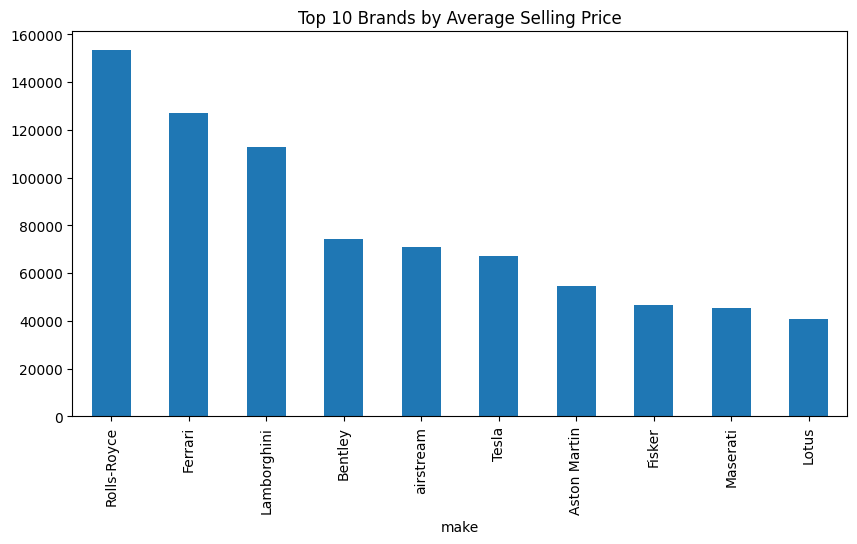

In [120]:
top_brands = (
    df.groupby('make')['sellingprice']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top_brands.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Brands by Average Selling Price')
plt.show()

**Business Insight** - Luxury brands dominate resale value.

## Visual 2: Top 10 Most Sold Models

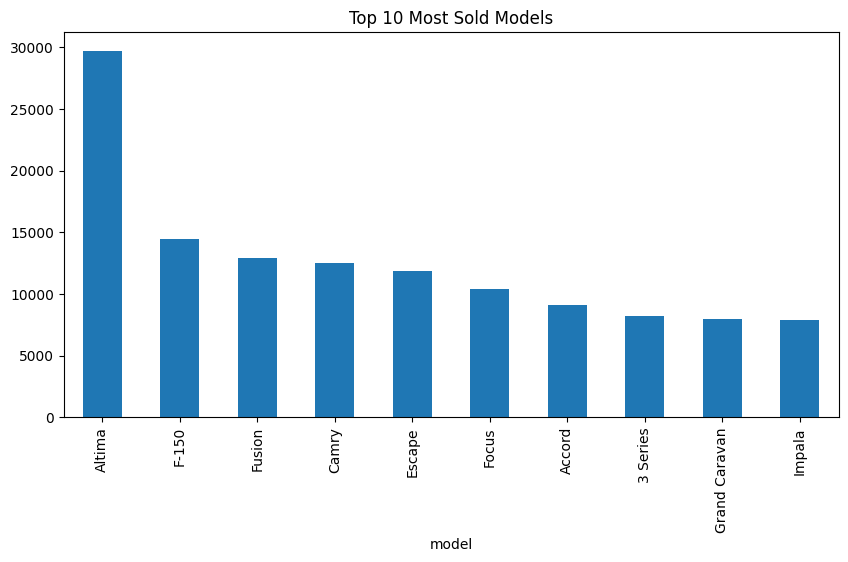

In [121]:
df['model'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Most Sold Models')

plt.show()

**Business Insight** - Altima dominates the used-car market.

## Visual 3: Selling Price Distribution

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

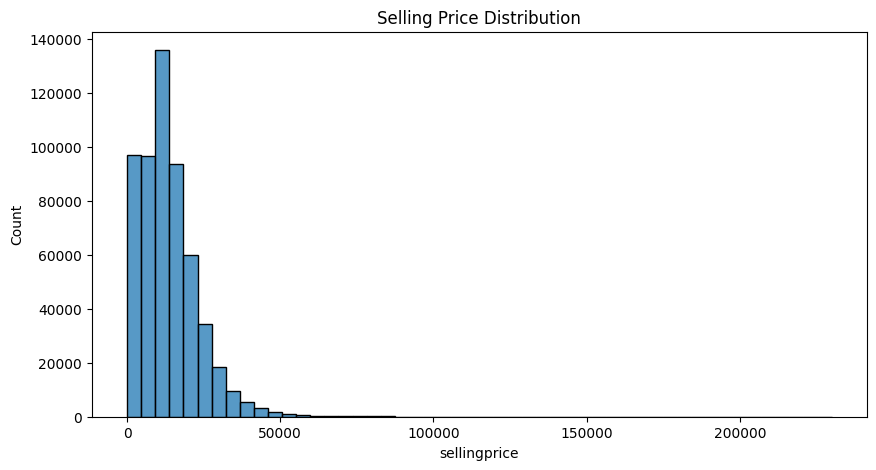

In [123]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['sellingprice'],
    bins=50
)

plt.title('Selling Price Distribution')

plt.show()

**Business Insight** - Most vehicles fall into lower-to-mid price ranges.

## Visual 4: Average Selling Price by Vehicle Age

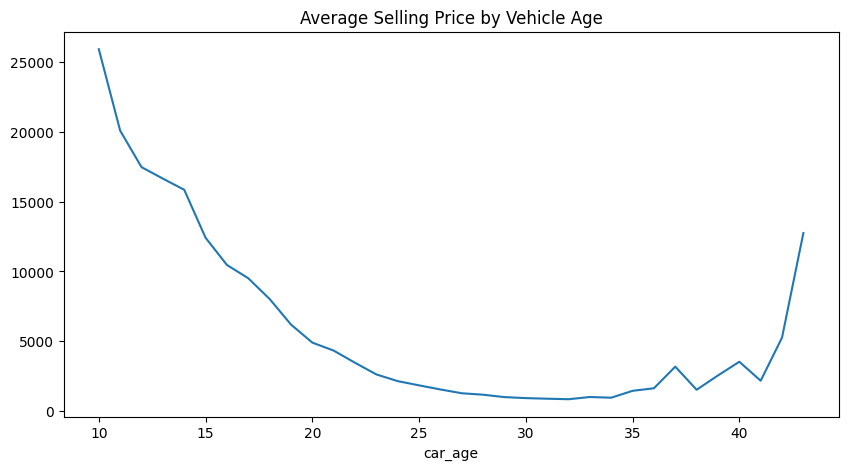

In [124]:
age_price = (
    df.groupby('car_age')['sellingprice']
      .mean()
)

age_price.plot(figsize=(10,5))

plt.title('Average Selling Price by Vehicle Age')

plt.show()

**Business Insight:** Depreciation significantly impacts vehicle value.

## Visual 5: Top States by Sales Volume

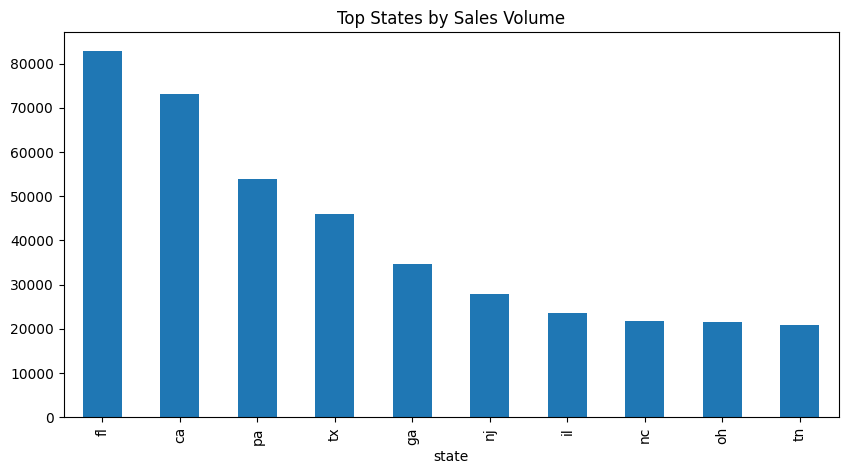

In [125]:
df['state'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top States by Sales Volume')

plt.show()

Business Insight: A few states account for a large portion of vehicle transactions.

# 3. Data Visualization and Insights

**Section Overview:** This section focuses on visualizing key patterns and relationships within the used car dataset using charts and graphs. Visualization techniques help transform raw data into meaningful insights by highlighting trends, correlations, distributions, and market behavior.

The objective is to identify factors influencing vehicle prices, understand customer preferences, detect anomalies, and support data-driven decision-making through graphical analysis.

## 3.1 Correlation Analysis of Numerical Features

In [126]:
kpi = {
    "Total Cars": len(df),
    "Unique Brands": df['make'].nunique(),
    "Unique Models": df['model'].nunique(),
    "Average Selling Price": round(df['sellingprice'].mean(),2),
    "Maximum Selling Price": df['sellingprice'].max()
}

kpi

{'Total Cars': 558837,
 'Unique Brands': 96,
 'Unique Models': 973,
 'Average Selling Price': np.float64(13611.33),
 'Maximum Selling Price': 230000.0}

**Objective:** Identify relationships between numerical variables such as selling price, odometer, condition, MMR, year, and car age.

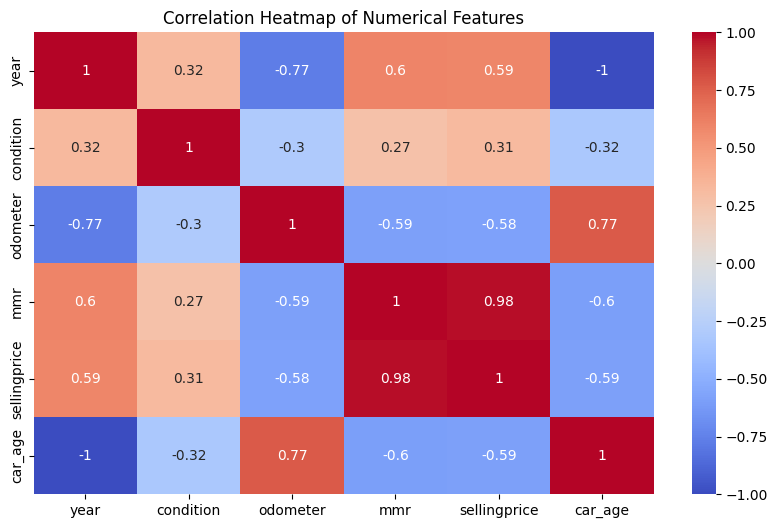

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Observation:** The correlation heatmap reveals the strength and direction of relationships between numerical variables. Selling price typically shows a positive correlation with MMR and vehicle condition, while showing a negative relationship with vehicle age and odometer readings.

**Business Insight:** Vehicle valuation models should prioritize MMR, condition, and vehicle age because these variables have the strongest influence on selling price.

## 3.2 Average Selling Price by Year

**Objective:** Analyze how vehicle manufacturing year impacts average selling price.

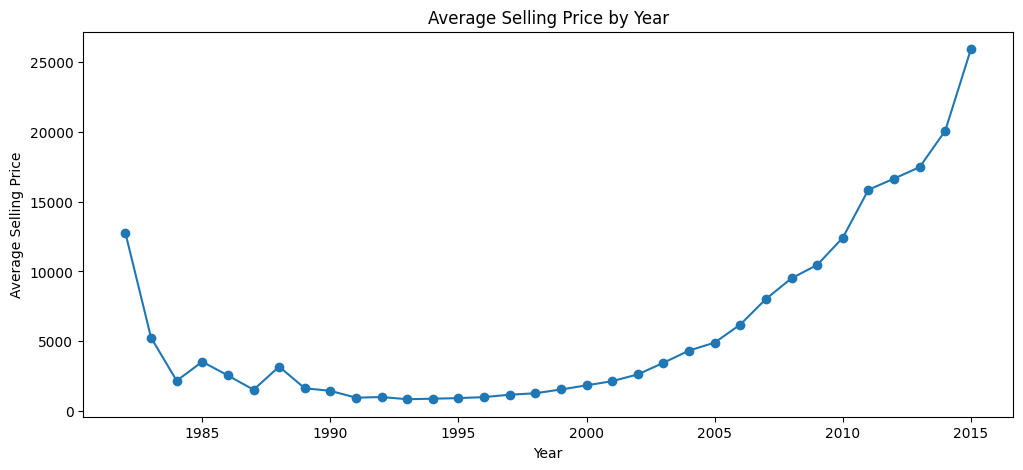

In [128]:
year_price = df.groupby('year')['sellingprice'].mean()

plt.figure(figsize=(12,5))

year_price.plot(
    marker='o'
)

plt.title("Average Selling Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Selling Price")

plt.show()

**Observation:** Average selling prices generally increase for newer vehicle model years. More recent vehicles command higher resale values due to lower depreciation and improved features.

**Business Insight:** Dealerships and resellers can maximize profits by focusing inventory acquisition on newer vehicle models.

## 3.3 Average Selling Price by Odometer

**Objective:** Analyze the relationship between mileage and vehicle selling price.

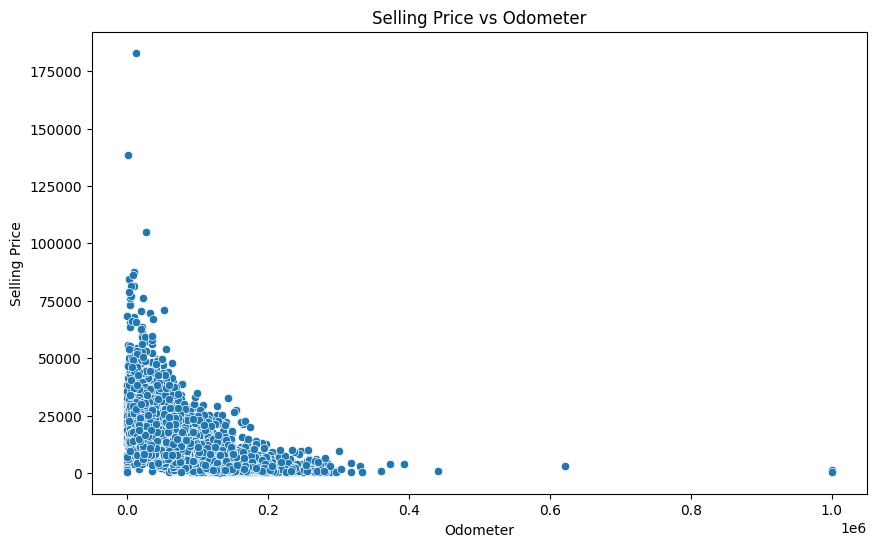

In [129]:
sample_df = df.sample(10000)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='odometer',
    y='sellingprice',
    data=sample_df
)

plt.title("Selling Price vs Odometer")
plt.xlabel("Odometer")
plt.ylabel("Selling Price")

plt.show()

**Observation:** A negative relationship is observed between odometer readings and selling price. Vehicles with higher mileage generally sell for lower prices.

**Business Insight:** Mileage is an important pricing factor and should be considered when determining vehicle resale value.

## 3.4 Number of Cars Sold by State

**Objective:** Identify regions with the highest vehicle sales activity.

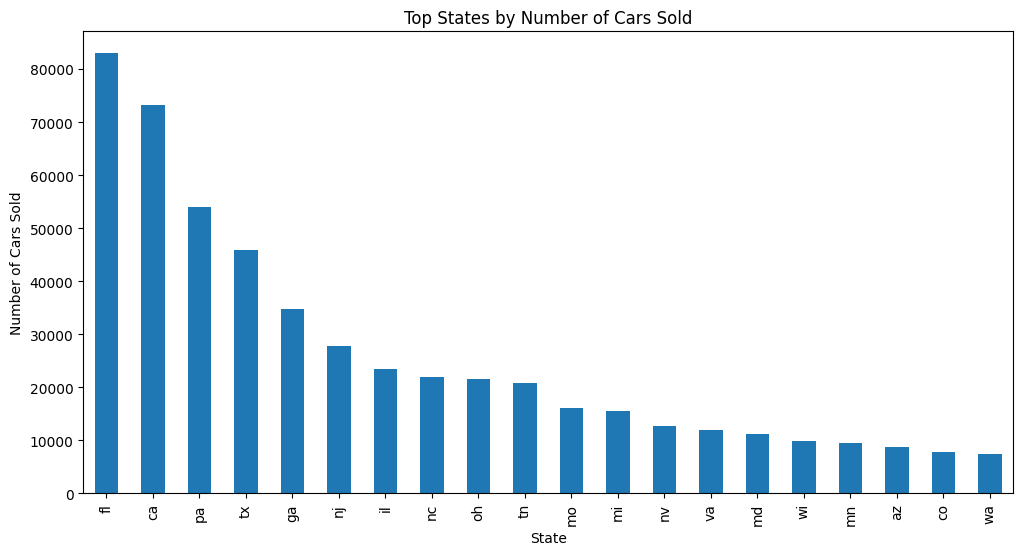

In [130]:
state_sales = df['state'].value_counts()

plt.figure(figsize=(12,6))

state_sales.head(20).plot(kind='bar')

plt.title("Top States by Number of Cars Sold")
plt.xlabel("State")
plt.ylabel("Number of Cars Sold")

plt.show()

In [131]:
state_sales.head(3)

,count
state,
fl,82945
ca,73148
pa,53907


**Observation:** Certain states contribute significantly more vehicle sales than others. These states represent major used-car market regions.

**Business Insight:** Marketing campaigns and inventory allocation can be prioritized in states with consistently high sales volumes.

## 3.5 Average Selling Price by Condition Score Ranges of Size 5

**Objective:** Determine how vehicle condition affects average selling price.

/tmp/ipykernel_877/2637852898.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('condition_group')['sellingprice']


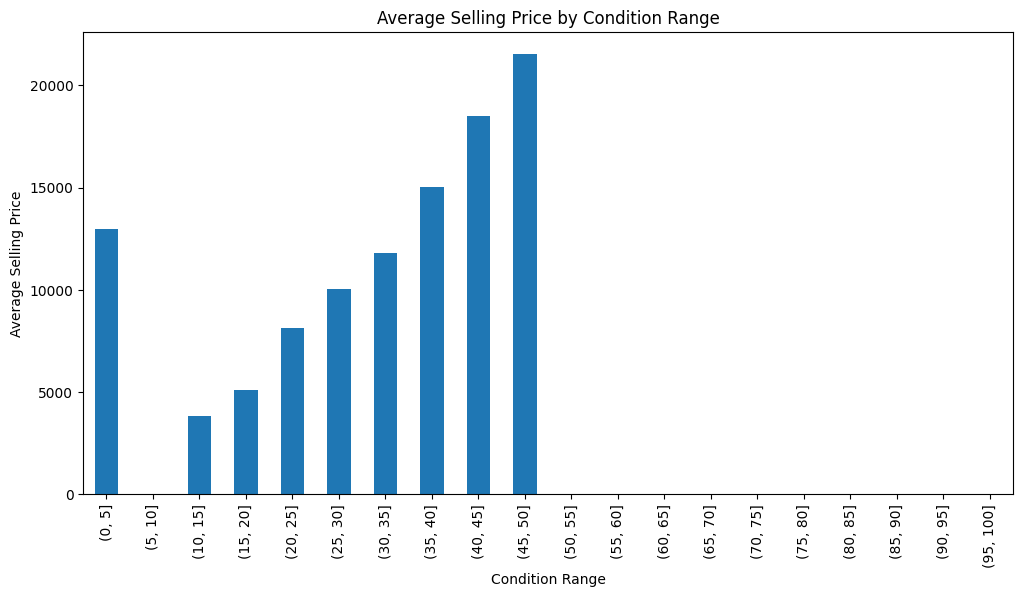

In [132]:
df['condition_group'] = pd.cut(
    df['condition'],
    bins=range(0,105,5)
)

avg_price = (
    df.groupby('condition_group')['sellingprice']
      .mean()
)

plt.figure(figsize=(12,6))

avg_price.plot(kind='bar')

plt.title("Average Selling Price by Condition Range")
plt.xlabel("Condition Range")
plt.ylabel("Average Selling Price")

plt.show()

**Observation:** Average selling prices generally increase as vehicle condition scores improve.

**Business Insight:** Maintaining vehicle condition can significantly improve resale value and profitability.

## 3.6 Number of Cars Sold by Condition Ranges of Size 10

/tmp/ipykernel_877/1791558703.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('condition_group_10')


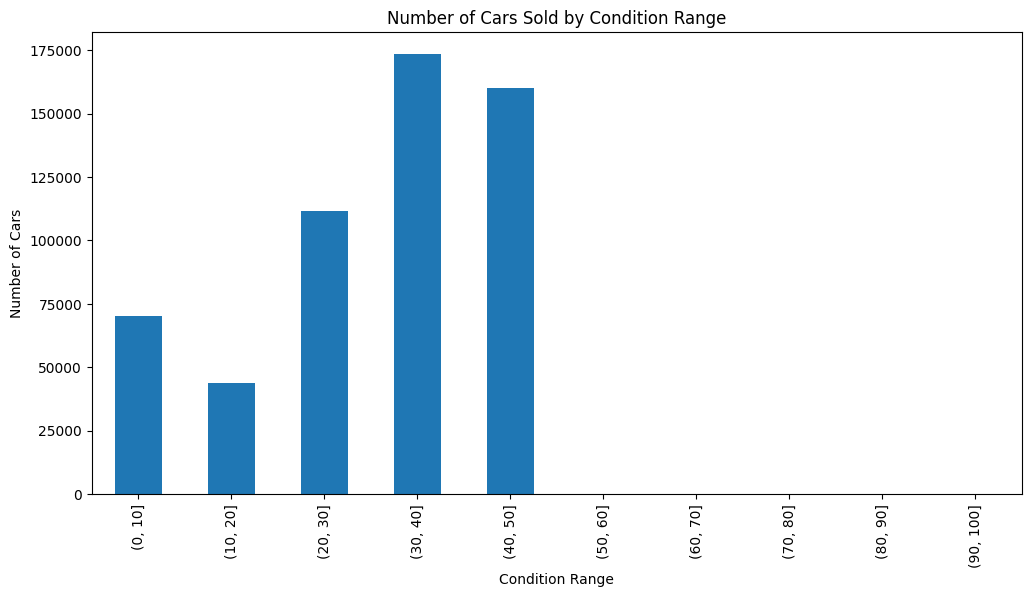

In [133]:
df['condition_group_10'] = pd.cut(
    df['condition'],
    bins=range(0,105,10)
)

condition_count = (
    df.groupby('condition_group_10')
      .size()
)

plt.figure(figsize=(12,6))

condition_count.plot(kind='bar')

plt.title("Number of Cars Sold by Condition Range")
plt.xlabel("Condition Range")
plt.ylabel("Number of Cars")

plt.show()

**Observation:** Most vehicles are concentrated within mid-to-high condition ranges.

**Business Insight:** Inventory planning should focus on the most common condition categories because they represent the largest market segment.

## 3.7 Box Plot of Selling Price by Color

**Objective:** Analyze selling price distributions across vehicle colors and identify outliers.

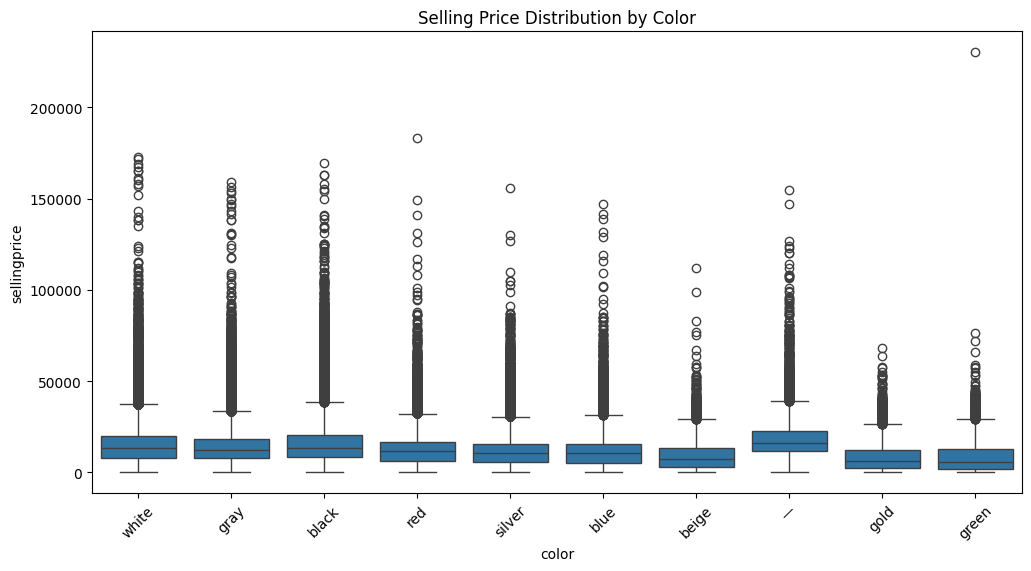

In [134]:
top_colors = df['color'].value_counts().head(10).index

filtered_df = df[
    df['color'].isin(top_colors)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    x='color',
    y='sellingprice',
    data=filtered_df
)

plt.xticks(rotation=45)

plt.title("Selling Price Distribution by Color")

plt.show()

**Observation:** Price distributions vary across colors, and several extreme outliers are visible.

**Business Insight:** Vehicle color may have a minor influence on resale value, but make, model, condition, and mileage have stronger effects.

## Outlier Removal

In [135]:
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)

IQR = Q3 - Q1

clean_df = df[
    (df['sellingprice'] >= Q1 - 1.5 * IQR)
    &
    (df['sellingprice'] <= Q3 + 1.5 * IQR)
]

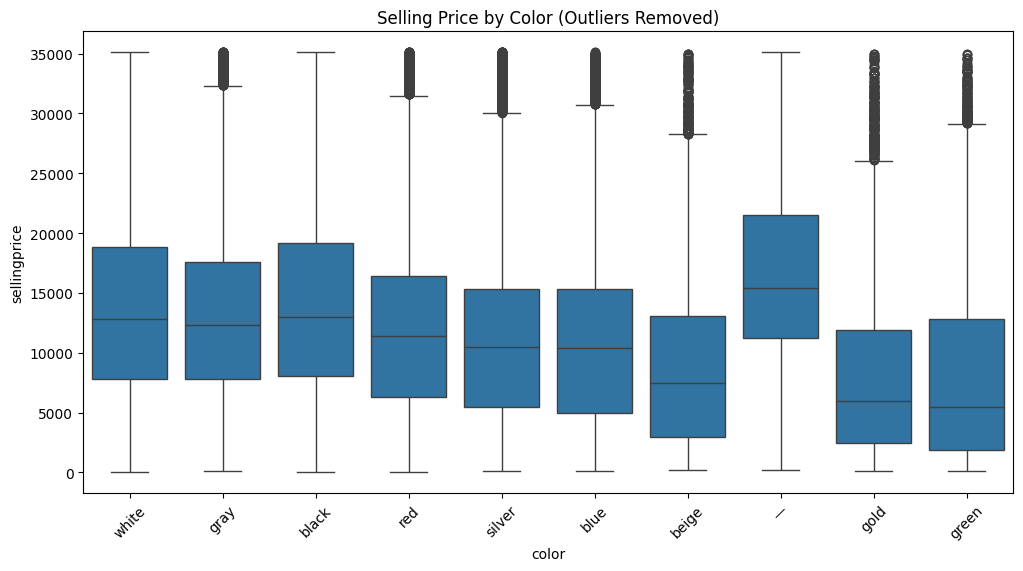

In [136]:
top_colors = clean_df['color'].value_counts().head(10).index

filtered_clean = clean_df[
    clean_df['color'].isin(top_colors)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    x='color',
    y='sellingprice',
    data=filtered_clean
)

plt.xticks(rotation=45)

plt.title("Selling Price by Color (Outliers Removed)")

plt.show()

## # 4. Conclusion

This analysis explored the used car dataset using data cleaning, exploratory data analysis, aggregation techniques, and visualizations.

Key findings include:

• The dataset contains 558,837 vehicle records and 16 attributes.

• Missing values were identified and appropriately handled using mode and median imputation techniques.

• No duplicate records were found.

• The average vehicle selling price is approximately 13,611.

• Luxury brands such as Rolls-Royce, Ferrari, and Lamborghini command the highest average selling prices.

• The Nissan Altima is the most frequently sold model in the dataset.

• Vehicle age and mileage negatively impact selling prices.

• Vehicle condition has a positive impact on resale value.

• Several data quality issues were identified, including numeric values within color fields and unusually high odometer readings.

Overall, the analysis demonstrates how data-driven techniques can be used to understand pricing trends, vehicle characteristics, and market behavior within the used car industry.
